# ENG4200 Coursework 1 — Logistic Regression for Stroke Prediction
**Author:** Patricia Natasha Munginga

**Student ID:** 3033388M

**Date:** October 2025

**Dataset:** healthcare-dataset-stroke-data.csv (Kaggle / UCU format)

This notebook presents a structured machine learning workflow for stroke predicition using logistic regression.
The focus is on rigorous experiment design, including dataset exploration, preprocessing, model training and validation, and performance evaluation.
Attention is given to reproducibility, imterpretability and computational efficiency with visualisations supporting the analysis and clear justification of modelling choices.

### Set up and Imports 

In [47]:
# Python core and scientific libraries
import time 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Dataset Visualization and exploration
import seaborn as sns

# Model selection and evaluation 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, GridSearchCV, validation_curve
# Pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import Ridge, LogisticRegression

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, precision_score,
    precision_recall_curve, average_precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

# Reproducibility
RNG = 42
np.random.seed(RNG)

### Exploratory Data Analysis

#### Dataset Overview 
The dataset contains 5,110 records with 12 features describing patients’ demographic and medical information. The target variable `stroke` is highly **imbalanced** with only around 5% positive stroke cases. This imbalance means that a simple model could achieve high accuracy by predicting “no stroke” for most cases, so F1 and ROC-AUC are more meaningful metrics. Moreover, the only feature with missing values is `bmi`.

In [48]:
""" Load Dataset """

DATA_PATH = r"healthcare-dataset-stroke-data.csv" # Set the path to the stroke dataset

df = pd.read_csv(DATA_PATH, sep = ',') 

# Quick integrity check
assert "stroke" in df.columns, "Expected 'stroke' column." 

print(df.shape)
display(df.head()) 

# Summary statistics (numerical + categorical)
display(df.describe(include = 'all')) 

# Check for missing data
print("\nMissing values per column:") 
print(df.isna().sum().sort_values(ascending=False)) 

# Check data balance 
print("\nTarget class distribution:")
print(df['stroke'].value_counts(normalize=True)*100)


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000



Missing values per column:
bmi                  201
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Target class distribution:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


#### Visual Exploration of Dataset

##### Numerical Feature Exploration
The numerical variables `age`, `avg_glucose_leve` and `bmi` display distinct distribution patterns:
- **Age** is roughly uniform but increases sharply among older patients. This skew aligns with the greater stroke risk in older individuals and explains their higher proportion within the prediction dataset.
- **Average glucose level** shows right-skewness, indicating a minority of patients with very high glucose values, a known medical risk factor.
- **BMI** is moderately right-skewed, with most patients falling in the healthy-to-overweight range.

##### Categorical Feature Exploration
The categorical visualisations (Bar graphs) highlight clear trends consistent with clinical knowledge:
- **Hypertension** and **heart disease** are both associated with higher stroke incidence (about 12% and 15% respectively). Individuals with these conditions have stroke rates roughly 3 times higher than those without, aligning with known clinical risk factors.
- **Smoking status** shows that both current and former smokers display higher stroke proportions than those who have never smoked, suggesting long-term vascular effects.
- **Work type** and **marital status** exhibit visible differences, where self-employed and married individuals show elevated stroke proportions — likely reflecting age and lifestyle correlations.
- **Gender** and **residence type** demonstrate minimum variation, suggesting these may not be strong standalone predictors in the dataset.
 

##### Correlation Insights
The correlation heatmap shows weak but meaningful relationships between key health indicators and stroke occurrence.
- **Age** has the strongest positive correlation with stroke (p = 0.25), aligning with established medical risk factors.
- **Hypertension**, **Heart disease** and show smaller positive correlations with stroke (p =0.13), consistent with their clinical importance but limited standalone predictive power.
- **Average glucose level** and **BMI** show very weak correlations (p < 0.1), implying they may interact with other features rather than directly determining the stroke likelihood.
 - Although `age`, `bmi`, and `hypertension ` and `heart disease` show the highest pairwise correlations among numeric features, the absolute values remain below 0.4, indicating weak relationships and no significant multicollinearity concerns

##### Class Imbalance
- Only around 5% of patients experienced a stroke, demonstrating severe class imbalance.
- Without correction, a model could achieve high accuracy by always predicting “no stroke”.

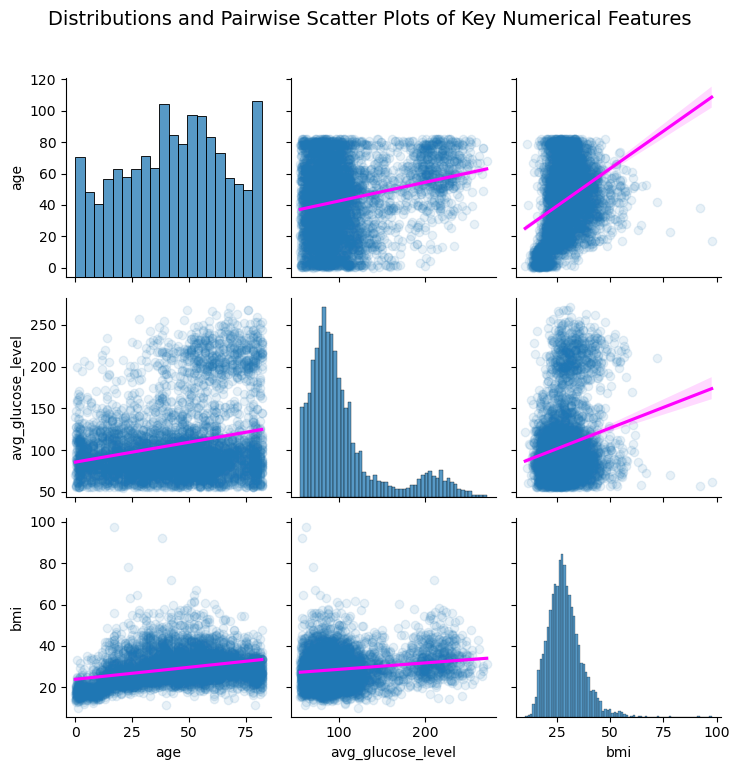

KeyboardInterrupt: 

In [49]:
""" Visual Exploration of Dataset """

# Plot Distributions and Pairwise scatter plot of key numerical features
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
g = sns.pairplot(df[numeric_cols], 
             kind='reg', 
             plot_kws={'line_kws':{'color':'magenta'}, 'scatter_kws': {'alpha': 0.1}})
g.fig.suptitle("Distributions and Pairwise Scatter Plots of Key Numerical Features", fontsize=14, y=1.02)
g.fig.tight_layout()
plt.show()

# Plot stroke occurrence in categorical variables clinically related to stroke likelihood
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_status']

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='stroke', data=df, palette='coolwarm')
    plt.title(f"Stroke Occurrence by {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.legend(title="Stroke", loc="upper right")
plt.suptitle("Stroke Occurrence Across Key Categorical Health Indicators", fontsize=14, y=1.02)    
plt.tight_layout()
plt.show()

# Plot stroke incidence in all categorical variables 
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Calculate stroke percentage and sample counts
    group = df.groupby(col)['stroke']
    stroke_rates = group.mean() * 100
    counts = group.count()
    
    # Plot stroke proportions
    sns.barplot(x=stroke_rates.index, y=stroke_rates.values, ax=axes[i],hue=stroke_rates.index, palette="muted", legend=False)
    axes[i].set_title(f"Stroke Incidence by {col}")
    axes[i].set_ylabel("Stroke %")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    # Adjust Y-limits to make room for annotations
    y_max = stroke_rates.max()
    axes[i].set_ylim(0, y_max * 1.25)  # Add 25% headroom
    
    # Annotate total sample count on top of each bar
    for j, val in enumerate(stroke_rates.values):
        axes[i].text(j, val + 0.2, f"n={counts.values[j]}", ha='center', va='bottom', fontsize=8, color='black')

for k in range(i+1, len(axes)): # Remove any unused subplots
    fig.delaxes(axes[k])

plt.suptitle("Stroke Incidence Across All Categorical Feautures", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Plot Spearman Rank correlation matrix
corr_features = ['age', 'avg_glucose_level', 'bmi', 
                 'hypertension', 'heart_disease', 'stroke']

corr_spearman = df[corr_features].corr(method='spearman')

fig = plt.figure(figsize = (6,5))
sns.heatmap(corr_spearman, annot=True, cmap="RdYlGn", vmin=-1, vmax=+1)
plt.title('Spearman Correlation Matrix')
plt.show()

# Visualize class imbalance
sns.countplot(x='stroke', data=df)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

### Data Splitting

The dataset was split into features (X) and target (y), with an 80/20 train-test split.
A stratified split was used to preserve the class imbalance ratio between stroke and non-stroke cases, ensuring both sets represent the original distribution.

In [ ]:
""" Training and Testing Dataset Splitting """

# Seperate features (X) and target (y)
X = df.drop(columns = ["stroke"]) 
y = df['stroke'] 

# Stratified split to preserve class ratio in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG 
)  

### Preprocessing

Separate preprocessing pipelines were applied to numeric and categorical variables using a `ColumnTransformer`.

- Numeric features (`age`, `bmi`, `avg_glucose_level`) were imputed using the median to minimize the influence of outliers and then standardized to ensure equal weighting in the model.
- Exploratory analysis revealed varying feature scales, justifying standardization to prevent dominant influence from high-magnitude variables like `average glucose level`.
- Categorical features (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) were `one-hot encoded` with drop='first' to avoid multicollinearity. The encoding allows the model to capture non-ordinal relationships while handle_unknown='ignore' ensures robustness when unseen categories appear during testing or deployment.

In [ ]:
""" Preprocessing Pipelines """

# Define categorical and numeric feature lists
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_features = ['age', 'bmi', 'avg_glucose_level']

# Define Transformations
categorical_transformer = Pipeline(steps = [("encoder", OneHotEncoder(drop = 'first', handle_unknown = "ignore"))]) # Convert categorical data to binary columns

numeric_transformer = Pipeline(steps = [("imputer", SimpleImputer(strategy = "median")), # Fill missing values
                                        ("scaler", StandardScaler())]) # Scale to mean = 0, std = 1

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers = [("cat", categorical_transformer, categorical_features), # Apply different transformations to different columns in parallel
                                                 ("num", numeric_transformer, numeric_features)])

print("Preprocessing pipeline successfully defined.")

Preprocessing pipeline successfully defined.


### Baseline Model

#### Logistic Regression Rationale

- Logistic Regression was chosen as a baseline classifier because it is interpretable, computationally efficient and well-suited for linearly separable problems. It models the log-odds of stroke occurrence as a linear function of input features.
- Given the strong class imbalance (~5% stroke cases), `class_weight='balanced'` was applied to assign higher penalty to misclassifying stroke cases, improving recall and ensuring fairness across classes.

***Model Assumptions and Limitations***

- Logistic Regression assumes linearity in log-odds between features and the target, independence of observations and low multicollinearity among predictors (verified via correlation analysis).
- While these assumptions generally hold, the model’s simplicity limits its ability to capture nonlinear relationships. However, the weak correlations among features indicate that stroke risk arises from multivariate interactions, justifying the use of logistic regression to model combined effects rather than single-variable thresholds.

In [ ]:
# BASELINE LOGISTIC REGRESSION MODEL (before tuning)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        random_state=RNG))
])

### Training and Validation

#### Cross-Validation 

A **Stratified 5-Fold Cross-Validation** was used to ensure each fold preserved the same class imbalance ratio as the full dataset.  This approach provides a fair estimate of generalisation performance and helps detect overfitting by comparing validation metrics across folds.

Four evaluation metrics were reported:
- **Accuracy** — overall correctness, though less informative under class imbalance.  
- **F1-score** — balance between precision and recall, reflecting overall model stability.  
- **Recall (Sensitivity)** — key metric, measuring how many actual stroke cases were correctly identified.  
- **ROC-AUC** — assesses how well the model distinguishes stroke from non-stroke cases across thresholds.

#### Cross-Validation Results Summary

- The model achieved a mean validation accuracy of **0.730 ± 0.015**, F1-score of **0.222**, recall of **0.789** and ROC-AUC of **0.837** across five folds. The small variation between folds indicates **low variance** (no overfitting), while the moderate scores suggest **some bias**, consistent with the linear nature of logistic regression.  
- Overall, the model demonstrates strong sensitivity and reliable generalisation, making it suitable for stroke detection tasks where identifying positive cases is more critical than avoiding false alarms.

Two versions of the logistic regression model were compared to demonstrate the effect of hyperparameter tuning:

1. **Baseline Model:** Logistic regression with default regularisation strength (`C=1.0`) evaluated using stratified 5-fold cross-validation.
2. **Tuned Model:** Logistic regression optimised via GridSearchCV using Recall, Precision and F1 as the main metrics to optimize.

In [ ]:
""" Cross Validation"""

# Stratified k-fold ensures each fold keeps the same stroke/non-stroke ratio
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# Cross-validation with multiple metrics
baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=("accuracy", "f1", "recall", "roc_auc", "precision"),
    return_train_score=True,
    n_jobs=-1
)

print("BASELINE CROSS-VALIDATION RESULTS")

print(f"Accuracy (train):  {baseline_cv['train_accuracy'].mean():.3f} ± {baseline_cv['train_accuracy'].std():.3f}")
print(f"F1 (train):        {baseline_cv['train_f1'].mean():.3f}")
print(f"Recall (train):    {baseline_cv['train_recall'].mean():.3f}")
print(f"ROC-AUC (train):   {baseline_cv['train_roc_auc'].mean():.3f}")
print(f"Precision (train): {baseline_cv['train_precision'].mean():.3f}")

print(f"\nAccuracy (val):  {baseline_cv['test_accuracy'].mean():.3f} ± {baseline_cv['test_accuracy'].std():.3f}")
print(f"F1 (val):        {baseline_cv['test_f1'].mean():.3f}")
print(f"Recall (val):    {baseline_cv['test_recall'].mean():.3f}")
print(f"ROC-AUC (val):   {baseline_cv['test_roc_auc'].mean():.3f}")
print(f"Precision (val): {baseline_cv['test_precision'].mean():.3f}")

# Train baseline model on full training data and record training time
t0 = time.time()
baseline_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

# Fit on full training data to test later
t1 = time.time()
baseline_pipeline.fit(X_train, y_train)
y_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]
y_pred_base = (y_proba_base >= 0.5).astype(int)
pred_time = time.time() - t1

print("\nBASELINE TEST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.3f}")
print(f"F1:       {f1_score(y_test, y_pred_base):.3f}")
print(f"Recall:   {recall_score(y_test, y_pred_base):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.3f}")

print(f"\nTrain time: {train_time*1000:.1f} ms | Predict time: {pred_time*1000:.1f} ms")

BASELINE CROSS-VALIDATION RESULTS
Accuracy (train):  0.733 ± 0.008
F1 (train):        0.230
Recall (train):    0.819
ROC-AUC (train):   0.844
Precision (train): 0.134

Accuracy (val):  0.730 ± 0.015
F1 (val):        0.222
Recall (val):    0.789
ROC-AUC (val):   0.837
Precision (val): 0.129

BASELINE TEST RESULTS
Accuracy: 0.745
F1:       0.230
Recall:   0.780
ROC-AUC:  0.843
Precision: 0.135

Train time: 41.9 ms | Predict time: 39.7 ms


### Hyperparameter Tuning

- In stroke prediction, accuracy alone can be misleading due to class imbalance (only  about 5% of cases are strokes). The model can achieve high accuracy on the imbalanced dataset by simply predicting the majority class(non-stroke) for every case.
- Instead, performance should be evaluated using recall, precision and F1-score, which better capture the model’s ability to detect rare but critical events.

***Recall:*** 
- Measures how many actual stroke cases were correctly identified.
- High recall is essential since missing a stroke case (false negative) can have severe consequences.
-  For stroke risk screening, the priority is to create a robust safety net. This means the model must be highly effective at catching potential stroke cases, even if it means there are more false alarms (false positives) compared to a model optimized for precision or accuracy.

***Precision:***
- Measures how many predicted stroke cases were actually correct.
- High precision ensures the model avoids excessive false positives, reducing unnecessary alarms or tests.

***F1-Score:***
- The harmonic mean of precision and recall, balancing both metrics.
- Useful when both missing strokes and raising false alarms are costly.

In [ ]:
# Grid Search for Logistic Regression (Recall-Optimized) 

# Define pipeline
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight='balanced',  # handle imbalance
        random_state=RNG))
])

# Parameter grid for tuning
param_grid = {
    "model__C": np.logspace(-3, 3, 8),  # Wider regularization range
    "model__penalty": ["l2", None],     # None =  no penalty
    "model__solver": ["lbfgs", "saga"], # Support for L2 and None
    "model__max_iter": [500, 1000, 2000] 
}

#Grid Search: optimise for recall but track multiple metrics
grid_search = GridSearchCV(
    clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring= ("accuracy", "f1", "recall", "roc_auc"),  
    refit = "recall",           # recall is used for the final model selection.
    n_jobs=-1,
    verbose=1
)

# Train GridSearchCV
t0 = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)
print(f"Grid search time: {grid_time:.2f} seconds")

# Evaluate best model on training data using multiple metrics 
best_model = grid_search.best_estimator_

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=skf,
    scoring=("accuracy", "f1", "recall", "roc_auc","precision"),
    return_train_score=True,
    n_jobs=-1
)

print("\nCROSS VALIDATION RESULTS (Best model)")

print(f"Accuracy (train):  {cv_results['train_accuracy'].mean():.3f} ± {cv_results['train_accuracy'].std():.3f}")
print(f"F1 (train):        {cv_results['train_f1'].mean():.3f}")
print(f"Recall (train):    {cv_results['train_recall'].mean():.3f}")
print(f"ROC-AUC (train):   {cv_results['train_roc_auc'].mean():.3f}")
print(f"Precision (train): {cv_results['train_precision'].mean():.3f}")

print(f"\nAccuracy (val):  {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"F1 (val):        {cv_results['test_f1'].mean():.3f}")
print(f"Recall (val):    {cv_results['test_recall'].mean():.3f}")
print(f"ROC-AUC (val):   {cv_results['test_roc_auc'].mean():.3f}")
print(f"Precision (val): {cv_results['test_precision'].mean():.3f}")

# Final test evaluation 
t1 = time.time()
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
pred_time = time.time() - t1

print("\nBEST MODEL TEST PERFORMANCE:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1:       {f1_score(y_test, y_pred):.3f}")
print(f"Recall:   {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Train (GridSearch) time: {grid_time*1000:.1f} ms | Predict time: {pred_time*1000:.1f} ms")


Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters: {'model__C': np.float64(0.001), 'model__max_iter': 500, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Recall: 0.8343589743589744
Grid search time: 22.90 seconds

CROSS VALIDATION RESULTS
Accuracy (train):  0.712 ± 0.003
F1 (train):        0.221
Recall (train):    0.840
ROC-AUC (train):   0.835
Precision (train): 0.127

Accuracy (val):  0.710 ± 0.019
F1 (val):        0.220
Recall (val):    0.834
ROC-AUC (val):   0.832
Precision (val): 0.126

BEST MODEL TEST PERFORMANCE:
Accuracy: 0.733
F1:       0.227
Recall:   0.800
ROC-AUC:  0.835
Precision: 0.132
Train (GridSearch) time: 22900.9 ms | Predict time: 11.7 ms


### Evaluation, Visualization and Justification

To improve model performance, GridSearchCV was used to fine-tune the logistic regression hyperparameters — primarily the regularization strength (**C**) — across multiple logarithmic ranges.  
The tuning objective prioritized recall, reflecting the clinical importance of minimizing missed stroke cases (false negatives).


#### Model Performance Comparison

| **Metric**     | **Baseline (C=1)** | **GridSearch (10⁻²–10²)** | **Extended Grid (10⁻³–10³)** | **Observation** |
|-----------------|--------------------|-----------------------------|-------------------------------|-----------------|
| **Accuracy**    | 0.745 | 0.742 | 0.733 | Slight overall decrease with stronger regularization |
| **F1-score**    | 0.230 | 0.228 | 0.227 | Small decline as model becomes more conservative |
| **Recall**      | 0.780 | 0.780 | **0.800** | Improved sensitivity to stroke cases |
| **Precision**   | 0.135 | 0.134 | 0.132 | Slight decrease (more false positives) |
| **ROC-AUC**     | 0.843 | 0.841 | 0.835 | Minor reduction; stability maintained |

#### Interpretation

- The **initial tuning (10⁻²–10²)** produced results nearly identical to the baseline, confirming that the default regularization strength (C=1) was already well-calibrated.  
- **Extending the search range (10⁻³–10³)** led to a **recall increase from 0.78 to 0.80**, demonstrating improved sensitivity — crucial for minimizing false negatives in medical contexts.  
- This gain came at the cost of **slightly lower precision (0.132)** and **F1-score (0.227)**, meaning the model now issues more false positives.  
- **Accuracy and ROC-AUC** declined marginally, reflecting the trade-off between sensitivity and specificity when optimizing for recall.

#### Conclusion

- Expanding the hyperparameter search improved recall, making the model more effective at identifying stroke cases — a valuable property for healthcare diagnostics, where false negatives are particularly costly.  
- However, the diminishing gains in F1 and precision suggest that the logistic regression model has reached its practical performance ceiling for this feature set.  
- This trade-off aligns with the clinical goal of early detection, where missing a stroke case is far more costly than issuing a false alarm.



<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

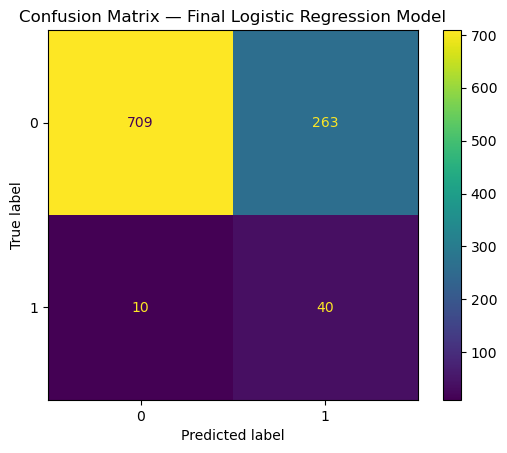

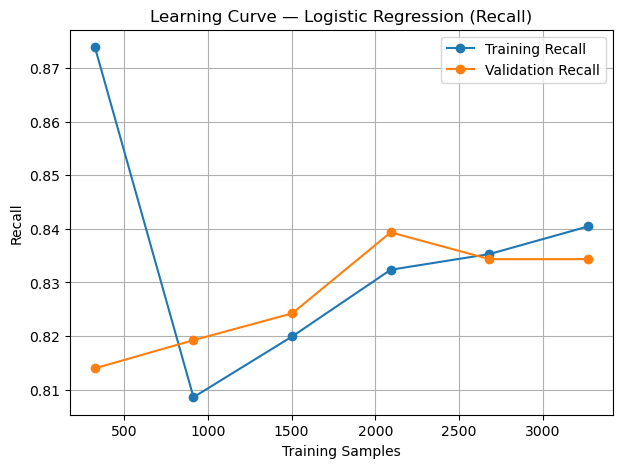

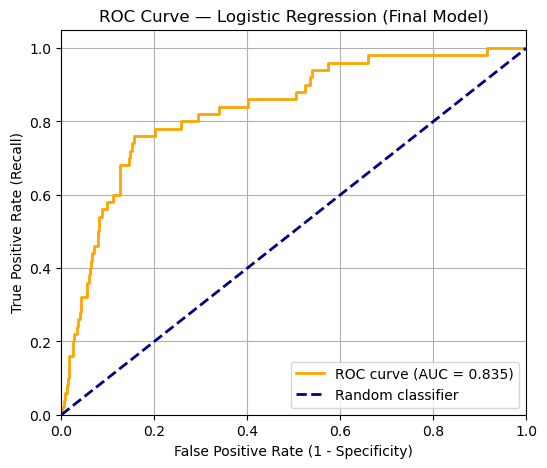

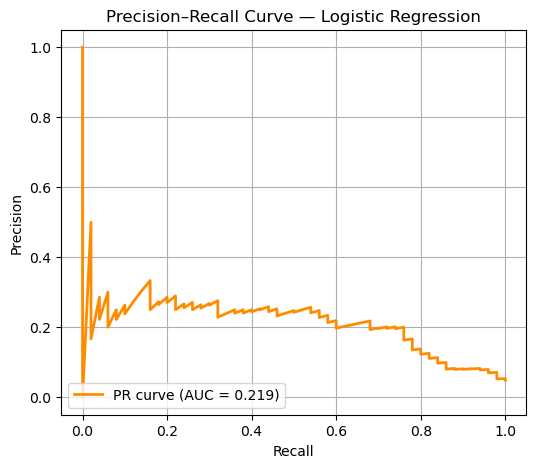

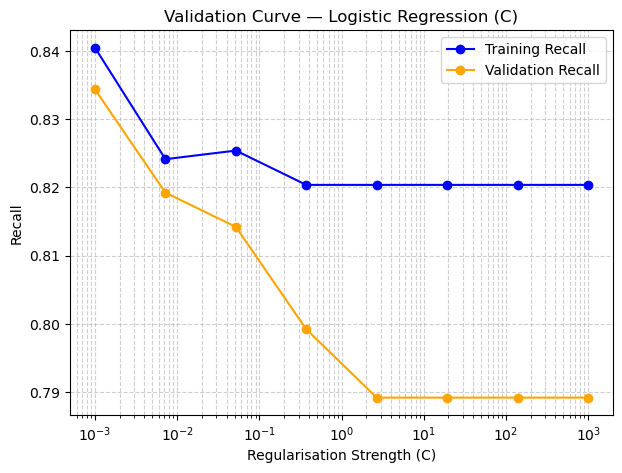

In [ ]:
""" Visualisation """

# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix — Final Logistic Regression Model")
plt.show()

# Learning curve (on best model)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=skf, scoring="recall", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG
)
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training Recall")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Recall")
plt.xlabel("Training Samples")
plt.ylabel("Recall")
plt.title("Learning Curve — Logistic Regression (Recall)")
plt.legend()
plt.grid(True)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression (Final Model)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Precision - Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve — Logistic Regression')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Validation curve using recall as the metric
Cs = np.logspace(-3, 3, 8)
train_scores, val_scores = validation_curve(
    best_model,
    X_train, y_train,
    param_name="model__C",
    param_range=Cs,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.semilogx(Cs, train_scores.mean(axis=1), marker="o", label="Training Recall", color="blue")
plt.semilogx(Cs, val_scores.mean(axis=1), marker="o", label="Validation Recall", color="orange")
plt.xlabel("Regularisation Strength (C)")
plt.ylabel("Recall")
plt.title("Validation Curve — Logistic Regression (C)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

#### Confusion Matrix Interpretation

The confusion matrix shows that out of all stroke predictions:
- **True Negatives (709):** Correctly identified non-stroke cases.  
- **False Positives (263):** Non-stroke cases incorrectly predicted as strokes.  
- **False Negatives (10):** Stroke cases the model failed to detect.  
- **True Positives (40):** Correctly identified stroke cases

- The model successfully detects most stroke cases (high recall, 0.80) with relatively few false negatives — a desirable outcome in a medical context where missing a positive case could have severe consequences.  
- However, the trade-off is a moderate number of false positives, slightly lowering precision (0.13).  
- This reflects a recall-oriented decision threshold , prioritising early detection over perfect accuracy, which aligns with clinical objectives in stroke prediction.

#### Learning Curve Interpretation
- The learning curve indicates a low-variance, moderately biased model.  
- The learning curve shows that training recall decreases slightly as more data is added, while validation recall steadily improves before both curves converge around 0.83–0.84.  
- This indicates that the logistic regression model generalises well and does not overfit.  
- The convergence of training and validation recall suggests that the model is learning effectively from available data and that additional samples may yield only marginal performance gains.

#### ROC Curve Interpretation
  
- The model’s AUC (Area Under the Curve) = 0.835, indicating strong discriminative ability — it can correctly distinguish between stroke and non-stroke cases about 83.5% of the time.  
- The steep rise near the y-axis shows that the model achieves high recall with relatively low false positive rates, which aligns well with the medical objective of prioritising sensitivity to stroke cases over precision.  
- This confirms that the logistic regression model maintains robust overall classification performance despite the dataset’s class imbalance.

#### Precison- Recall curve Interpretation

- The Precision–Recall (PR) curve highlights the trade-off between **precision** (the proportion of correct positive predictions) and **recall** (the proportion of actual positives detected).  
- The model achieves an **AUC = 0.219**. This low precision reflects the model’s tendency to generate false positives. 
- Overall, the curve confirms that the logistic regression model is tuned for **high recall** and **early detection**, ensuring most stroke cases are flagged even if it means sacrificing precision.

#### Validation Curve Interpretation

- The validation curve shows how the model’s **recall** changes with varying levels of regularisation strength (C).  
- **Low C values (10⁻³ – 10⁻²)** correspond to strong regularisation, slightly reducing model flexibility but maintaining high generalisation.  
- **High C values (≥ 10⁰)** weaken regularisation, allowing the model to fit the training data more closely but offering no gain in recall on the validation set.  
- Both curves plateau around **C ≈ 1**, indicating that beyond this point, the model stops improving and may even begin to overfit.  
- The small gap between training and validation recall suggests **low variance** and good generalisation.  
- Overall, the model performs consistently across the range, confirming that logistic regression’s recall performance is stable and not overly sensitive to regularisation strength.

### Runtime and Performance Analysis

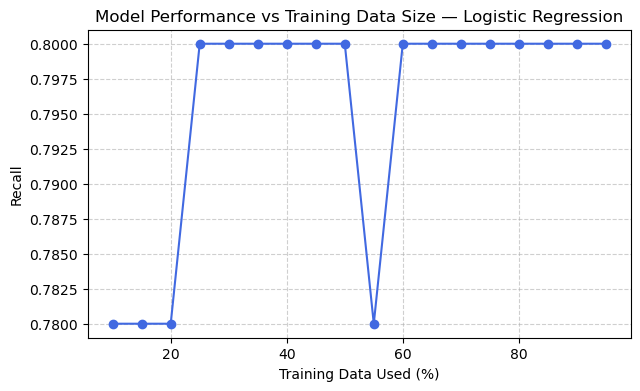

C:\Users\patri\AppData\Local\Temp\ipykernel_30284\4135467539.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


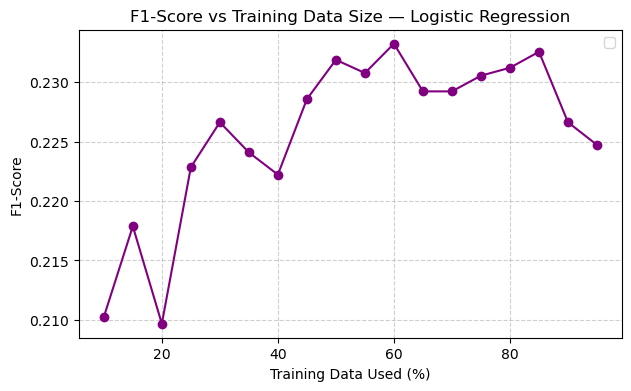

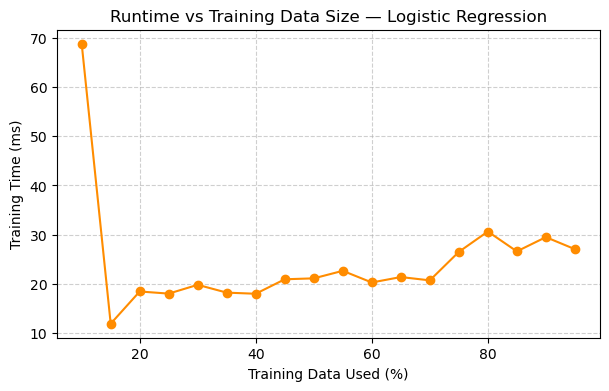

In [50]:
fractions = np.arange(0.1, 1.0, 0.05)  
recalls, f1_scores, train_times = [], [], []

for frac in fractions:
    # Stratified sample to preserve class balance
    X_sample, _, y_sample, _ = train_test_split(
        X_train, y_train, train_size=frac, stratify=y_train, random_state=RNG
    )
    
    # Train model on subset
    t0 = time.time()
    best_model.fit(X_sample, y_sample)
    train_time = time.time() - t0
    train_times.append(train_time)
    
    # Evaluate recall on test set
    y_pred_sample = best_model.predict(X_test)

    # Compute metrics
    recalls.append(recall_score(y_test, y_pred_sample))
    f1_scores.append(f1_score(y_test, y_pred_sample))


# Recall vs Training Data Size 
plt.figure(figsize=(7, 4))
plt.plot(np.array(fractions) * 100, recalls, marker="o", color="royalblue")
plt.title("Model Performance vs Training Data Size — Logistic Regression")
plt.xlabel("Training Data Used (%)")
plt.ylabel("Recall")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Plot F1 vs Training Data Size ---
plt.figure(figsize=(7, 4))
plt.plot(np.array(fractions) * 100, f1_scores, marker="o", color="purple")
plt.title("F1-Score vs Training Data Size — Logistic Regression")
plt.xlabel("Training Data Used (%)")
plt.ylabel("F1-Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Runtime vs Training Data Size 
plt.figure(figsize=(7, 4))
plt.plot(np.array(fractions) * 100, np.array(train_times) * 1000, 
         marker="o", color="darkorange")
plt.title("Runtime vs Training Data Size — Logistic Regression")
plt.xlabel("Training Data Used (%)")
plt.ylabel("Training Time (ms)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


#### Model Scalability and Data Efficiency

- **Recall vs. Training Size:**  
  - Recall stabilises around 0.78–0.80 even with smaller samples, suggesting that the model quickly learns the key decision boundary for detecting stroke cases.
  - Adding more data yields diminishing returns, indicating sufficient representativeness of the current dataset.

- **F1-Score vs. Training Size:**  
  - The F1-score remains relatively consistent (0.21–0.23) as data size grows.  
  - This stability implies that the trade-off between precision and recall does not significantly change, reflecting balanced generalisation performance.

- **Runtime vs. Training Size:**  
  - Training time increases linearly with data size, confirming the expected computational scalability of logistic regression. 
  - Even at full data capacity, runtime remains efficient (under 30 ms), reinforcing the model’s suitability for real-time medical screening applications.

**Overall:**  
The learning dynamics indicate a low-variance, low-bias model that generalises well across varying data sizes. Performance plateaus early, suggesting that logistic regression has reached its expressiveness limit for this feature set — further gains would likely require non-linear or ensemble models.

### Reproducibility and Reporting



In [ ]:
import sklearn, sys, seaborn
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn:", seaborn.__version__)

print("\nPipelines used:")
print("Classification:", clf_pipeline)

Python: 3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:37) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.3.3
Pandas: 2.3.2
scikit-learn: 1.7.2
seaborn: 0.13.2

Pipelines used:
Classification: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
           

### Mini Model Card

- **Objective:**  Predict whether a patient will experience a stroke based on health and demographic features.

- **Data:** Stroke dataset with 5110 entries; features include age, gender, hypertension, heart disease, marital status, work type, residence type, average glucose level, BMI, and smoking status; CSV is comma-separated.

- **Validation:** 5-fold stratified cross-validation on the training set; stratified train-test split to preserve class balance; GridSearchCV for parameter tuning and final evaluation on an untouched test set.

- **Key metrics:** Reported metrics include accuracy, F1 score, recall and ROC-AUC. With a strong focus on recall.

- **Strengths / limitations:** Logistic regression provides interpretability; however, class imbalance (~5% stroke cases) may reduce sensitivity for minority class. Preprocessing required for missing BMI values and categorical encoding.

- **Ethical notes / misuse risks:** Predictions depend on dataset demographics and may not generalize to other populations; model is not a medical diagnostic tool and should not be used for clinical decision-making without expert oversight.